In [11]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split # To split the data
from sklearn.metrics import mean_squared_error     # To calculate the error

# --- PREPROCESSING FUNCTION (Strictly Unchanged) ---
def preprocess_data(df, is_train=True, train_stats=None):
    
    # 1. Fill Missing Numerical
    if is_train:
        stats = {
            'Supplier_Reliability_median': df['Supplier_Reliability'].median(),
            'Equipment_Height_median': df['Equipment_Height'].median(),
            'Equipment_Width_median': df['Equipment_Width'].median(),
            'Equipment_Weight_median': df['Equipment_Weight'].median(),
            'Equipment_Value_median': df['Equipment_Value'].median()
        }
    else:
        stats = train_stats

    df['Supplier_Reliability'] = df['Supplier_Reliability'].fillna(stats['Supplier_Reliability_median'])
    df['Equipment_Height'] = df['Equipment_Height'].fillna(stats['Equipment_Height_median'])
    df['Equipment_Width'] = df['Equipment_Width'].fillna(stats['Equipment_Width_median'])
    df['Equipment_Weight'] = df['Equipment_Weight'].fillna(stats['Equipment_Weight_median'])
    df['Equipment_Value'] = df['Equipment_Value'].fillna(stats['Equipment_Value_median'])
    
    # 2. Fill Missing Categorical
    if is_train:
        stats['Equipment_Type_mode'] = df['Equipment_Type'].mode()[0]
        stats['Transport_Method_mode'] = df['Transport_Method'].mode()[0]
        stats['Rural_Hospital_mode'] = df['Rural_Hospital'].mode()[0]
        
    df['Equipment_Type'] = df['Equipment_Type'].fillna(stats['Equipment_Type_mode'])
    df['Transport_Method'] = df['Transport_Method'].fillna(stats['Transport_Method_mode'])
    df['Rural_Hospital'] = df['Rural_Hospital'].fillna(stats['Rural_Hospital_mode'])
    
    # 3. Feature Engineering (Dates)
    df['Order_Placed_Date'] = pd.to_datetime(df['Order_Placed_Date'], errors='coerce')
    df['Delivery_Date'] = pd.to_datetime(df['Delivery_Date'], errors='coerce')
    df['Delivery_Time_Days'] = (df['Delivery_Date'] - df['Order_Placed_Date']).dt.days
    df['Delivery_Time_Days'] = df['Delivery_Time_Days'].apply(lambda x: 0 if (x < 0 or pd.isna(x)) else x)
    df['Order_Year'] = df['Order_Placed_Date'].dt.year
    df['Order_Month'] = df['Order_Placed_Date'].dt.month
    df['Order_Day_of_Week'] = df['Order_Placed_Date'].dt.dayofweek
    
    if is_train:
        stats['Order_Year_mode'] = df['Order_Year'].mode()[0]
        stats['Order_Month_mode'] = df['Order_Month'].mode()[0]
        stats['Order_Day_of_Week_mode'] = df['Order_Day_of_Week'].mode()[0]
    
    df['Order_Year'] = df['Order_Year'].fillna(stats['Order_Year_mode'])
    df['Order_Month'] = df['Order_Month'].fillna(stats['Order_Month_mode'])
    df['Order_Day_of_Week'] = df['Order_Day_of_Week'].fillna(stats['Order_Day_of_Week_mode'])
    
    # 4. Additional Feature Engineering
    df['Value_per_Weight'] = df['Equipment_Value'] / (df['Equipment_Weight'] + 1)
    df['Equipment_Area'] = df['Equipment_Height'] * df['Equipment_Width']
    df['Is_Weekend'] = df['Order_Day_of_Week'].isin([5, 6]).astype(int)

    # 5. Encoding
    binary_cols = ['CrossBorder_Shipping', 'Urgent_Shipping', 'Installation_Service', 
                   'Fragile_Equipment', 'Rural_Hospital']
    for col in binary_cols:
        if 'Yes' in df[col].unique():
            df[col] = df[col].map({'Yes': 1, 'No': 0})
        else: 
            df[col] = df[col].map({'No': 0}).fillna(0)

    if 'Wealthy' in df['Hospital_Info'].unique():
        df['Hospital_Info'] = df['Hospital_Info'].map({'Wealthy': 1, 'Working Class': 0})
    else:
        df['Hospital_Info'] = df['Hospital_Info'].map({'Working Class': 0}).fillna(0)
        
    df = pd.get_dummies(df, columns=['Equipment_Type', 'Transport_Method'], drop_first=True)
    
    # 6. Drop Useless Columns
    cols_to_drop = ['Hospital_Id', 'Supplier_Name', 'Hospital_Location', 
                    'Order_Placed_Date', 'Delivery_Date']
    df = df.drop(columns=cols_to_drop, errors='ignore')
    
    if is_train:
        return df, stats
    else:
        return df

# --- 1. LOAD AND PREPROCESS DATA ---
print("Loading and preprocessing data...")
df_train_orig = pd.read_csv("train.csv")
df_train_clean, train_stats = preprocess_data(df_train_orig, is_train=True)

# --- 2. PREPARE FULL TRAINING DATA ---
y_full = df_train_clean['Transport_Cost'].clip(lower=0)
X_full = df_train_clean.drop(columns=['Transport_Cost'])

# --- 3. CREATE VALIDATION SET FOR ERROR CHECKING ---
print("Creating validation set...")
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)
y_train_split_log = np.log1p(y_train_split)

# --- 4. TRAIN AND EVALUATE MODEL ---
print("Training model for evaluation...")
gradient_boost_params = {
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 4,
    'subsample': 0.8,
    'loss': 'squared_error',
    'random_state': 42
}
eval_model = GradientBoostingRegressor(**gradient_boost_params)
eval_model.fit(X_train_split, y_train_split_log)

print("Evaluating model...")
val_preds_log = eval_model.predict(X_val)
val_preds_dollar = np.expm1(val_preds_log)

# --- 5. CALCULATE AND PRINT THE ERROR ---
mse = mean_squared_error(y_val, val_preds_dollar)
rmse = np.sqrt(mse)
print("\n--- MODEL EVALUATION ---")
print(f"Mean Squared Error (MSE) on Validation Set: {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE) on Validation Set: ${rmse:,.2f}")
print("------------------------\n")


# --- 6. PREPARE FINAL TEST DATA FOR SUBMISSION ---
print("Loading and preprocessing test.csv for submission...")
df_test_orig = pd.read_csv("test.csv")
submission_ids = df_test_orig['Hospital_Id'].copy()
df_test_clean = preprocess_data(df_test_orig, is_train=False, train_stats=train_stats)

# Align test columns to match the training columns
X_test_final = df_test_clean.reindex(columns=X_full.columns, fill_value=0)


# --- 7. RE-TRAIN MODEL ON 100% OF DATA ---
print("Re-training model on 100% of data for final submission...")
y_full_log = np.log1p(y_full) # Log transform the full target variable
final_model = GradientBoostingRegressor(**gradient_boost_params)
final_model.fit(X_full, y_full_log)


# --- 8. MAKE FINAL PREDICTIONS ---
print("Making final predictions on test.csv...")
preds_log = final_model.predict(X_test_final)
preds_dollar = np.expm1(preds_log)
preds_dollar = np.maximum(preds_dollar, 0) # Final safety check


# --- 9. CREATE SUBMISSION FILE ---
submission = pd.DataFrame({'Hospital_Id': submission_ids, 'Transport_Cost': preds_dollar})
submission.to_csv("submission_gb.csv", index=False)

print("\n✓ submission.csv created successfully!")
print("First few predictions:")
print(submission.head())



Loading and preprocessing data...


C:\Users\hrush\AppData\Local\Temp\ipykernel_25080\2531562275.py:39: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order_Placed_Date'] = pd.to_datetime(df['Order_Placed_Date'], errors='coerce')
C:\Users\hrush\AppData\Local\Temp\ipykernel_25080\2531562275.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Delivery_Date'] = pd.to_datetime(df['Delivery_Date'], errors='coerce')


Creating validation set...
Training model for evaluation...
Evaluating model...

--- MODEL EVALUATION ---
Mean Squared Error (MSE) on Validation Set: 1,554,130,549.49
Root Mean Squared Error (RMSE) on Validation Set: $39,422.46
------------------------

Loading and preprocessing test.csv for submission...
Re-training model on 100% of data for final submission...


C:\Users\hrush\AppData\Local\Temp\ipykernel_25080\2531562275.py:39: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order_Placed_Date'] = pd.to_datetime(df['Order_Placed_Date'], errors='coerce')
C:\Users\hrush\AppData\Local\Temp\ipykernel_25080\2531562275.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Delivery_Date'] = pd.to_datetime(df['Delivery_Date'], errors='coerce')


Making final predictions on test.csv...

✓ submission.csv created successfully!
First few predictions:
            Hospital_Id  Transport_Cost
0          fffe33003400      226.816035
1  fffe3700330036003600       30.262032
2  fffe3300390038003400     1889.832318
3      fffe310030003900      117.618824
4  fffe3700330031003200      530.285385


Loading and preprocessing data...


C:\Users\hrush\AppData\Local\Temp\ipykernel_7324\790374198.py:43: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

C:\Users\hrush\AppData\Local\Temp\ipykernel_7324\790374198.py:44: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

[I 2025-10-22 22:42:53,787] A new study created in memory with name: no-name-25be3714-4845-4068-8e78-a23cf47f1b52


Creating validation set for hyperparameter tuning...

Starting hyperparameter tuning for AdaBoost with Optuna...


[I 2025-10-22 22:42:54,548] Trial 0 finished with value: 46814.01329912802 and parameters: {'n_estimators': 97, 'learning_rate': 0.48201235092109357, 'loss': 'exponential'}. Best is trial 0 with value: 46814.01329912802.
[I 2025-10-22 22:42:58,104] Trial 1 finished with value: 46838.65957723352 and parameters: {'n_estimators': 458, 'learning_rate': 0.10297109116125161, 'loss': 'exponential'}. Best is trial 0 with value: 46814.01329912802.
[I 2025-10-22 22:42:59,230] Trial 2 finished with value: 46758.98894423428 and parameters: {'n_estimators': 167, 'learning_rate': 0.2575130073831284, 'loss': 'square'}. Best is trial 2 with value: 46758.98894423428.
[I 2025-10-22 22:43:00,402] Trial 3 finished with value: 46801.936134357704 and parameters: {'n_estimators': 149, 'learning_rate': 0.12103033746933536, 'loss': 'square'}. Best is trial 2 with value: 46758.98894423428.
[I 2025-10-22 22:43:03,189] Trial 4 finished with value: 46659.56142830891 and parameters: {'n_estimators': 330, 'learning_


--- OPTUNA TUNING COMPLETE ---
Best RMSE found: $39,044.53
Best parameters found:
{'n_estimators': 57, 'learning_rate': 0.0015733401436729658, 'loss': 'exponential'}
----------------------------

Displaying optimization history plot...


C:\Users\hrush\AppData\Local\Temp\ipykernel_7324\790374198.py:139: ExperimentalWarning:

optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.



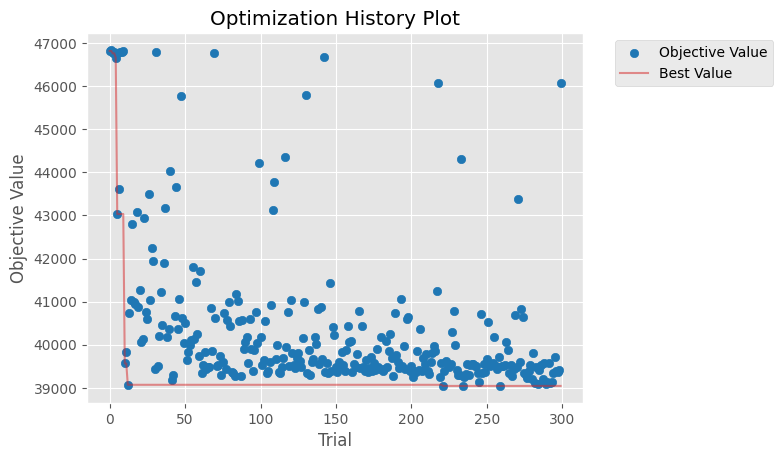

C:\Users\hrush\AppData\Local\Temp\ipykernel_7324\790374198.py:43: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

C:\Users\hrush\AppData\Local\Temp\ipykernel_7324\790374198.py:44: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.




Loading and preprocessing test.csv for submission...
Re-training AdaBoost model on 100% of data using best parameters...
Making final predictions on test.csv...

✓ submission.csv created successfully!
First few predictions:
            Hospital_Id  Transport_Cost
0          fffe33003400      232.379124
1  fffe3700330036003600      192.998387
2  fffe3300390038003400     1062.749000
3      fffe310030003900      127.403000
4  fffe3700330031003200      424.975302


In [6]:
import pandas as pd
import numpy as np
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import optuna
# Import the specific matplotlib visualizer from optuna
from optuna.visualization.matplotlib import plot_optimization_history
import matplotlib.pyplot as plt

# --- PREPROCESSING FUNCTION (Strictly Unchanged) ---
def preprocess_data(df, is_train=True, train_stats=None):
    
    # 1. Fill Missing Numerical
    if is_train:
        stats = {
            'Supplier_Reliability_median': df['Supplier_Reliability'].median(),
            'Equipment_Height_median': df['Equipment_Height'].median(),
            'Equipment_Width_median': df['Equipment_Width'].median(),
            'Equipment_Weight_median': df['Equipment_Weight'].median(),
            'Equipment_Value_median': df['Equipment_Value'].median()
        }
    else:
        stats = train_stats

    df['Supplier_Reliability'] = df['Supplier_Reliability'].fillna(stats['Supplier_Reliability_median'])
    df['Equipment_Height'] = df['Equipment_Height'].fillna(stats['Equipment_Height_median'])
    df['Equipment_Width'] = df['Equipment_Width'].fillna(stats['Equipment_Width_median'])
    df['Equipment_Weight'] = df['Equipment_Weight'].fillna(stats['Equipment_Weight_median'])
    df['Equipment_Value'] = df['Equipment_Value'].fillna(stats['Equipment_Value_median'])
    
    # 2. Fill Missing Categorical
    if is_train:
        stats['Equipment_Type_mode'] = df['Equipment_Type'].mode()[0]
        stats['Transport_Method_mode'] = df['Transport_Method'].mode()[0]
        stats['Rural_Hospital_mode'] = df['Rural_Hospital'].mode()[0]
        
    df['Equipment_Type'] = df['Equipment_Type'].fillna(stats['Equipment_Type_mode'])
    df['Transport_Method'] = df['Transport_Method'].fillna(stats['Transport_Method_mode'])
    df['Rural_Hospital'] = df['Rural_Hospital'].fillna(stats['Rural_Hospital_mode'])
    
    # 3. Feature Engineering (Dates)
    df['Order_Placed_Date'] = pd.to_datetime(df['Order_Placed_Date'], errors='coerce')
    df['Delivery_Date'] = pd.to_datetime(df['Delivery_Date'], errors='coerce')
    df['Delivery_Time_Days'] = (df['Delivery_Date'] - df['Order_Placed_Date']).dt.days
    df['Delivery_Time_Days'] = df['Delivery_Time_Days'].apply(lambda x: 0 if (x < 0 or pd.isna(x)) else x)
    df['Order_Year'] = df['Order_Placed_Date'].dt.year
    df['Order_Month'] = df['Order_Placed_Date'].dt.month
    df['Order_Day_of_Week'] = df['Order_Placed_Date'].dt.dayofweek
    
    if is_train:
        stats['Order_Year_mode'] = df['Order_Year'].mode()[0]
        stats['Order_Month_mode'] = df['Order_Month'].mode()[0]
        stats['Order_Day_of_Week_mode'] = df['Order_Day_of_Week'].mode()[0]
    
    df['Order_Year'] = df['Order_Year'].fillna(stats['Order_Year_mode'])
    df['Order_Month'] = df['Order_Month'].fillna(stats['Order_Month_mode'])
    df['Order_Day_of_Week'] = df['Order_Day_of_Week'].fillna(stats['Order_Day_of_Week_mode'])
    
    # 4. Additional Feature Engineering
    df['Value_per_Weight'] = df['Equipment_Value'] / (df['Equipment_Weight'] + 1)
    df['Equipment_Area'] = df['Equipment_Height'] * df['Equipment_Width']
    df['Is_Weekend'] = df['Order_Day_of_Week'].isin([5, 6]).astype(int)

    # 5. Encoding
    binary_cols = ['CrossBorder_Shipping', 'Urgent_Shipping', 'Installation_Service', 
                   'Fragile_Equipment', 'Rural_Hospital']
    for col in binary_cols:
        if 'Yes' in df[col].unique():
            df[col] = df[col].map({'Yes': 1, 'No': 0})
        else: 
            df[col] = df[col].map({'No': 0}).fillna(0)

    if 'Wealthy' in df['Hospital_Info'].unique():
        df['Hospital_Info'] = df['Hospital_Info'].map({'Wealthy': 1, 'Working Class': 0})
    else:
        df['Hospital_Info'] = df['Hospital_Info'].map({'Working Class': 0}).fillna(0)
        
    df = pd.get_dummies(df, columns=['Equipment_Type', 'Transport_Method'], drop_first=True)
    
    # 6. Drop Useless Columns
    cols_to_drop = ['Hospital_Id', 'Supplier_Name', 'Hospital_Location', 
                    'Order_Placed_Date', 'Delivery_Date']
    df = df.drop(columns=cols_to_drop, errors='ignore')
    
    if is_train:
        return df, stats
    else:
        return df

# --- 1. LOAD AND PREPROCESS DATA ---
print("Loading and preprocessing data...")
df_train_orig = pd.read_csv("train.csv")
df_train_clean, train_stats = preprocess_data(df_train_orig, is_train=True)

# --- 2. PREPARE FULL TRAINING DATA ---
y_full = df_train_clean['Transport_Cost'].clip(lower=0)
X_full = df_train_clean.drop(columns=['Transport_Cost'])

# --- 3. CREATE VALIDATION SET FOR TUNING ---
print("Creating validation set for hyperparameter tuning...")
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)
y_train_split_log = np.log1p(y_train_split)

# --- 4. OPTUNA HYPERPARAMETER TUNING FOR ADABOOST ---
def objective(trial):
    """Define the objective function for Optuna to optimize for AdaBoost."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 1.0, log=True),
        'loss': trial.suggest_categorical('loss', ['linear', 'square', 'exponential']),
        'random_state': 42
    }
    
    model = AdaBoostRegressor(**params)
    model.fit(X_train_split, y_train_split_log)
    
    preds_log = model.predict(X_val)
    preds_dollar = np.expm1(preds_log)
    
    rmse = np.sqrt(mean_squared_error(y_val, preds_dollar))
    return rmse

print("\nStarting hyperparameter tuning for AdaBoost with Optuna...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=300)

best_params = study.best_params
print("\n--- OPTUNA TUNING COMPLETE ---")
print(f"Best RMSE found: ${study.best_value:,.2f}")
print("Best parameters found:")
print(best_params)
print("----------------------------\n")

# --- 5. VISUALIZE THE OPTIMIZATION HISTORY WITH MATPLOTLIB ---
print("Displaying optimization history plot...")
plot_optimization_history(study)
plt.show()


# --- 6. PREPARE FINAL TEST DATA FOR SUBMISSION ---
print("\nLoading and preprocessing test.csv for submission...")
df_test_orig = pd.read_csv("test.csv")
submission_ids = df_test_orig['Hospital_Id'].copy()
df_test_clean = preprocess_data(df_test_orig, is_train=False, train_stats=train_stats)
X_test_final = df_test_clean.reindex(columns=X_full.columns, fill_value=0)

# --- 7. RE-TRAIN MODEL ON 100% OF DATA WITH BEST PARAMS ---
print("Re-training AdaBoost model on 100% of data using best parameters...")
y_full_log = np.log1p(y_full)
final_model = AdaBoostRegressor(**best_params, random_state=42)
final_model.fit(X_full, y_full_log)

# --- 8. MAKE FINAL PREDICTIONS ---
print("Making final predictions on test.csv...")
preds_log = final_model.predict(X_test_final)
preds_dollar = np.expm1(preds_log)
preds_dollar = np.maximum(preds_dollar, 0)

# --- 9. CREATE SUBMISSION FILE ---
submission = pd.DataFrame({'Hospital_Id': submission_ids, 'Transport_Cost': preds_dollar})
submission.to_csv("submission_ada_hyp_300.csv", index=False)

print("\n✓ submission.csv created successfully!")
print("First few predictions:")
print(submission.head())



Loading and preprocessing data...


C:\Users\hrush\AppData\Local\Temp\ipykernel_21356\3408048419.py:49: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order_Placed_Date'] = pd.to_datetime(df['Order_Placed_Date'], errors='coerce')
C:\Users\hrush\AppData\Local\Temp\ipykernel_21356\3408048419.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Delivery_Date'] = pd.to_datetime(df['Delivery_Date'], errors='coerce')
[I 2025-10-23 19:38:57,646] A new study created in memory with name: no-name-5881e368-5151-4839-a08a-2ca82cbfaa7e


Creating validation set for hyperparameter tuning...

Starting hyperparameter tuning for CatBoost with Optuna...


[I 2025-10-23 19:39:14,712] Trial 0 finished with value: 48624.25882672713 and parameters: {'iterations': 437, 'learning_rate': 0.2536999076681772, 'depth': 9, 'l2_leaf_reg': 0.00969582664451522}. Best is trial 0 with value: 48624.25882672713.
[I 2025-10-23 19:39:17,796] Trial 1 finished with value: 42513.6400004522 and parameters: {'iterations': 240, 'learning_rate': 0.01699897838270077, 'depth': 4, 'l2_leaf_reg': 4.589458612326471}. Best is trial 1 with value: 42513.6400004522.
[I 2025-10-23 19:39:26,581] Trial 2 finished with value: 40292.71592576317 and parameters: {'iterations': 641, 'learning_rate': 0.11114989443094977, 'depth': 4, 'l2_leaf_reg': 50.01479828856935}. Best is trial 2 with value: 40292.71592576317.
[I 2025-10-23 19:39:40,765] Trial 3 finished with value: 39969.06971367336 and parameters: {'iterations': 850, 'learning_rate': 0.020589728197687916, 'depth': 5, 'l2_leaf_reg': 6.8240955406304e-07}. Best is trial 3 with value: 39969.06971367336.
[I 2025-10-23 19:39:49,074


--- OPTUNA TUNING COMPLETE ---
Best RMSE found: $28,112.53
Best parameters found:
{'iterations': 524, 'learning_rate': 0.22333341423663286, 'depth': 4, 'l2_leaf_reg': 7.922557197366563e-05}
----------------------------

Displaying optimization history plot...


C:\Users\hrush\AppData\Local\Temp\ipykernel_21356\3408048419.py:154: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study)


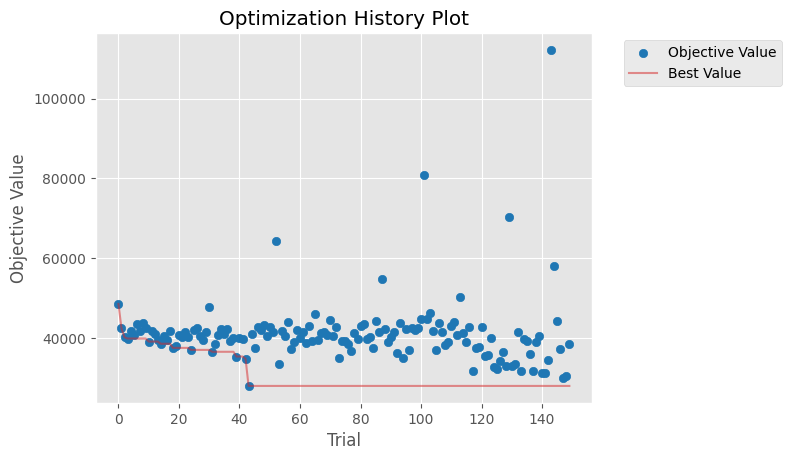

C:\Users\hrush\AppData\Local\Temp\ipykernel_21356\3408048419.py:49: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order_Placed_Date'] = pd.to_datetime(df['Order_Placed_Date'], errors='coerce')



Loading and preprocessing test.csv for submission...


C:\Users\hrush\AppData\Local\Temp\ipykernel_21356\3408048419.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Delivery_Date'] = pd.to_datetime(df['Delivery_Date'], errors='coerce')


Re-training CatBoost model on 100% of data using best parameters...
Making final predictions on test.csv...

✓ submission_catboost_optuna.csv created successfully!
First few predictions:
            Hospital_Id  Transport_Cost
0          fffe33003400      323.695962
1  fffe3700330036003600        0.480372
2  fffe3300390038003400     2139.584996
3      fffe310030003900      127.628421
4  fffe3700330031003200      728.314374


In [ ]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import optuna
from optuna.samplers import TPESampler
from optuna.visualization.matplotlib import plot_optimization_history
import matplotlib.pyplot as plt

# --- PREPROCESSING FUNCTION (MODIFIED FOR CATBOOST) ---
def preprocess_data(df, is_train=True, train_stats=None):
    
    # 1. Fill Missing Numerical (Same as before)
    if is_train:
        stats = {
            'Supplier_Reliability_median': df['Supplier_Reliability'].median(),
            'Equipment_Height_median': df['Equipment_Height'].median(),
            'Equipment_Width_median': df['Equipment_Width'].median(),
            'Equipment_Weight_median': df['Equipment_Weight'].median(),
            'Equipment_Value_median': df['Equipment_Value'].median()
        }
    else:
        stats = train_stats

    # Handle potential NaNs in stats dictionary
    for k, v in stats.items():
        if pd.isna(v):
            stats[k] = 0

    df['Supplier_Reliability'] = df['Supplier_Reliability'].fillna(stats['Supplier_Reliability_median'])
    df['Equipment_Height'] = df['Equipment_Height'].fillna(stats['Equipment_Height_median'])
    df['Equipment_Width'] = df['Equipment_Width'].fillna(stats['Equipment_Width_median'])
    df['Equipment_Weight'] = df['Equipment_Weight'].fillna(stats['Equipment_Weight_median'])
    df['Equipment_Value'] = df['Equipment_Value'].fillna(stats['Equipment_Value_median'])
    
    # 2. Fill Missing Categorical (Same as before)
    if is_train:
        # Handle potential empty mode
        stats['Equipment_Type_mode'] = df['Equipment_Type'].mode()[0] if not df['Equipment_Type'].mode().empty else 'Type A'
        stats['Transport_Method_mode'] = df['Transport_Method'].mode()[0] if not df['Transport_Method'].mode().empty else 'Road'
        stats['Rural_Hospital_mode'] = df['Rural_Hospital'].mode()[0] if not df['Rural_Hospital'].mode().empty else 'No'
        
    df['Equipment_Type'] = df['Equipment_Type'].fillna(stats['Equipment_Type_mode'])
    df['Transport_Method'] = df['Transport_Method'].fillna(stats['Transport_Method_mode'])
    df['Rural_Hospital'] = df['Rural_Hospital'].fillna(stats['Rural_Hospital_mode'])
    
    # 3. Feature Engineering (Dates) (Same as before)
    df['Order_Placed_Date'] = pd.to_datetime(df['Order_Placed_Date'], errors='coerce')
    df['Delivery_Date'] = pd.to_datetime(df['Delivery_Date'], errors='coerce')
    df['Delivery_Time_Days'] = (df['Delivery_Date'] - df['Order_Placed_Date']).dt.days
    df['Delivery_Time_Days'] = df['Delivery_Time_Days'].apply(lambda x: 0 if (x < 0 or pd.isna(x)) else x)
    df['Order_Year'] = df['Order_Placed_Date'].dt.year
    df['Order_Month'] = df['Order_Placed_Date'].dt.month
    df['Order_Day_of_Week'] = df['Order_Placed_Date'].dt.dayofweek
    
    if is_train:
        stats['Order_Year_mode'] = df['Order_Year'].mode()[0] if not df['Order_Year'].mode().empty else 2020
        stats['Order_Month_mode'] = df['Order_Month'].mode()[0] if not df['Order_Month'].mode().empty else 1
        stats['Order_Day_of_Week_mode'] = df['Order_Day_of_Week'].mode()[0] if not df['Order_Day_of_Week'].mode().empty else 0
    
    df['Order_Year'] = df['Order_Year'].fillna(stats['Order_Year_mode'])
    df['Order_Month'] = df['Order_Month'].fillna(stats['Order_Month_mode'])
    df['Order_Day_of_Week'] = df['Order_Day_of_Week'].fillna(stats['Order_Day_of_Week_mode'])
    
    # 4. Additional Feature Engineering (Same as before)
    df['Value_per_Weight'] = df['Equipment_Value'] / (df['Equipment_Weight'] + 1)
    df['Equipment_Area'] = df['Equipment_Height'] * df['Equipment_Width']
    df['Is_Weekend'] = df['Order_Day_of_Week'].isin([5, 6]).astype(int)

    # 5. Encoding (Binaries) (Same as before)
    binary_cols = ['CrossBorder_Shipping', 'Urgent_Shipping', 'Installation_Service', 
                   'Fragile_Equipment', 'Rural_Hospital']
    for col in binary_cols:
        if col in df.columns:
            df[col] = df[col].map({'Yes': 1, 'No': 0}).fillna(0)

    if 'Hospital_Info' in df.columns:
        df['Hospital_Info'] = df['Hospital_Info'].map({'Wealthy': 1, 'Working Class': 0}).fillna(0)
        
    # --- THIS IS THE KEY CHANGE ---
    # We NO LONGER one-hot encode. CatBoost will handle these columns.
    # df = pd.get_dummies(df, columns=['Equipment_Type', 'Transport_Method'], drop_first=True)
    
    # 6. Drop Useless Columns (Same as before)
    cols_to_drop = ['Hospital_Id', 'Supplier_Name', 'Hospital_Location', 
                    'Order_Placed_Date', 'Delivery_Date']
    df = df.drop(columns=cols_to_drop, errors='ignore')
    
    if is_train:
        return df, stats
    else:
        return df

# --- 1. LOAD AND PREPROCESS DATA ---
print("Loading and preprocessing data...")
df_train_orig = pd.read_csv("train.csv")
df_train_clean, train_stats = preprocess_data(df_train_orig, is_train=True)

# --- 2. PREPARE FULL TRAINING DATA ---
y_full = df_train_clean['Transport_Cost'].clip(lower=0)
X_full = df_train_clean.drop(columns=['Transport_Cost'])

# --- 3. CREATE VALIDATION SET FOR TUNING ---
print("Creating validation set for hyperparameter tuning...")
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)
y_train_split_log = np.log1p(y_train_split)

# --- 4. OPTUNA HYPERPARAMETER TUNING FOR CATBOOST ---

# Define the list of categorical feature names
categorical_features = ['Equipment_Type', 'Transport_Method']

def objective(trial):
    """Define the objective function for Optuna to optimize for CatBoost."""
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 100.0, log=True),
        'random_seed': 42,
        'verbose': False # Suppress training output
    }
    
    model = CatBoostRegressor(**params)
    
    model.fit(X_train_split, y_train_split_log, 
              cat_features=categorical_features # <-- Tell CatBoost which columns are categorical
             )
    
    preds_log = model.predict(X_val)
    preds_dollar = np.expm1(preds_log)
    
    rmse = np.sqrt(mean_squared_error(y_val, preds_dollar))
    return rmse

print("\nStarting hyperparameter tuning for CatBoost with Optuna...")
# Create a sampler with a fixed seed for reproducibility
sampler = TPESampler(seed=42)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=150)

best_params = study.best_params
print("\n--- OPTUNA TUNING COMPLETE ---")
print(f"Best RMSE found: ${study.best_value:,.2f}")
print("Best parameters found:")
print(best_params)
print("----------------------------\n")

# --- 5. VISUALIZE THE OPTIMIZATION HISTORY WITH MATPLOTLIB ---
print("Displaying optimization history plot...")
plot_optimization_history(study)
plt.show()

# --- 6. PREPARE FINAL TEST DATA FOR SUBMISSION ---
print("\nLoading and preprocessing test.csv for submission...")
df_test_orig = pd.read_csv("test.csv")
submission_ids = df_test_orig['Hospital_Id'].copy()
df_test_clean = preprocess_data(df_test_orig, is_train=False, train_stats=train_stats)
X_test_final = df_test_clean.reindex(columns=X_full.columns, fill_value=0)

# --- 7. RE-TRAIN MODEL ON 100% OF DATA WITH BEST PARAMS ---
print("Re-training CatBoost model on 100% of data using best parameters...")
y_full_log = np.log1p(y_full)
final_model = CatBoostRegressor(**best_params, random_seed=42, verbose=False) # Use best params

final_model.fit(X_full, y_full_log, 
                cat_features=categorical_features # <-- Tell CatBoost which columns are categorical
               )

# --- 8. MAKE FINAL PREDICTIONS ---
print("Making final predictions on test.csv...")
preds_log = final_model.predict(X_test_final)
preds_dollar = np.expm1(preds_log)
preds_dollar = np.maximum(preds_dollar, 0)

# --- 9. CREATE SUBMISSION FILE ---
submission = pd.DataFrame({'Hospital_Id': submission_ids, 'Transport_Cost': preds_dollar})
submission.to_csv("submission_catboost_optuna.csv", index=False)

print("\n✓ submission_catboost_optuna.csv created successfully!")
print("First few predictions:")
print(submission.head())


Loading and preprocessing data with ADVANCED (v3) features...


[I 2025-10-24 17:22:07,544] A new study created in memory with name: no-name-9b0bb74d-59c3-4093-ba0d-88210773081d


Using K-Fold Cross-Validation for hyperparameter tuning...

Starting FINE-TUNED hyperparameter search (300 trials, 5-Fold CV)...
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!!! WARNING: This will take ~5x longer to complete.    !!!
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


[I 2025-10-24 17:22:20,738] Trial 0 finished with value: 192564.42329134032 and parameters: {'n_estimators': 550, 'max_depth': 30, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 0.8312037280884873}. Best is trial 0 with value: 192564.42329134032.
[I 2025-10-24 17:22:32,620] Trial 1 finished with value: 192271.98465094386 and parameters: {'n_estimators': 462, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 0.941614515559209}. Best is trial 1 with value: 192271.98465094386.
[I 2025-10-24 17:22:44,756] Trial 2 finished with value: 192790.60350303125 and parameters: {'n_estimators': 408, 'max_depth': 30, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 0.8363649934414201}. Best is trial 1 with value: 192271.98465094386.
[I 2025-10-24 17:22:56,640] Trial 3 finished with value: 192025.42303445347 and parameters: {'n_estimators': 473, 'max_depth': 19, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 0.8582458280396084


--- OPTUNA FINE-TUNING COMPLETE ---
Best 5-Fold CV RMSE found: $190,784.46
Best parameters found:
{'n_estimators': 765, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.9906774088766663}
----------------------------

Displaying optimization history plot...


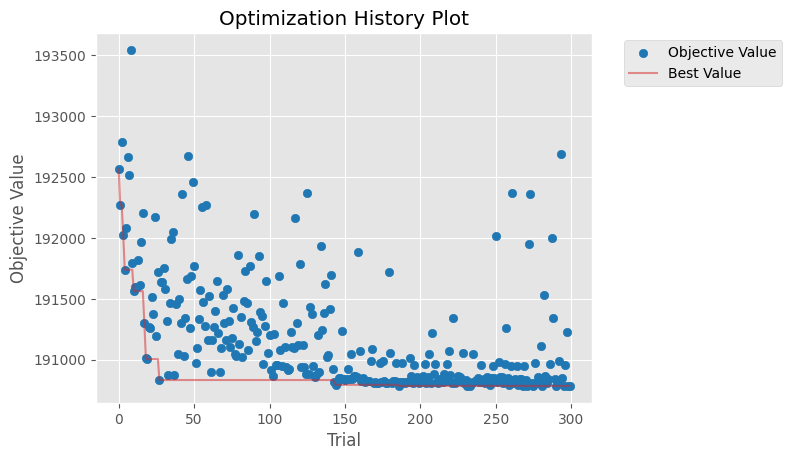


Loading and preprocessing test.csv for submission...
Re-training Random Forest model on 100% of data using best parameters...
Making final predictions on test.csv...

✓ submission_rf_v3_fine_tuned.csv created successfully!
First few predictions:
            Hospital_Id  Transport_Cost
0          fffe33003400      364.113612
1  fffe3700330036003600       33.032681
2  fffe3300390038003400      695.056070
3      fffe310030003900      155.513005
4  fffe3700330031003200      628.343955


In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold # <-- New import
from sklearn.metrics import mean_squared_error
import optuna
from optuna.samplers import TPESampler
from optuna.visualization.matplotlib import plot_optimization_history
import matplotlib.pyplot as plt
import warnings

# --- HIDE NON-CRITICAL WARNINGS ---
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=Warning) # Catches TqdmWarning and others


# --- PREPROCESSING FUNCTION (Your Winning v3) ---
def preprocess_data(df, is_train=True, train_stats=None):
    """
    Your winning v3 preprocessing function.
    """
    
    # === 1. Handle Missingness ===
    df['Supplier_Reliability_is_Missing'] = df['Supplier_Reliability'].isna().astype(int)
    
    if is_train:
        stats = {
            'Supplier_Reliability_fill': -1, 
            'Equipment_Height_median': df['Equipment_Height'].median(),
            'Equipment_Width_median': df['Equipment_Width'].median(),
            'Equipment_Weight_median': df['Equipment_Weight'].median(),
            'Equipment_Value_median': df['Equipment_Value'].median()
        }
    else:
        stats = train_stats

    for k, v in stats.items():
        if pd.isna(v): stats[k] = 0

    df['Supplier_Reliability'] = df['Supplier_Reliability'].fillna(stats['Supplier_Reliability_fill'])
    df['Equipment_Height'] = df['Equipment_Height'].fillna(stats['Equipment_Height_median'])
    df['Equipment_Width'] = df['Equipment_Width'].fillna(stats['Equipment_Width_median'])
    df['Equipment_Weight'] = df['Equipment_Weight'].fillna(stats['Equipment_Weight_median'])
    df['Equipment_Value'] = df['Equipment_Value'].fillna(stats['Equipment_Value_median'])
    
    df['Equipment_Type'] = df['Equipment_Type'].fillna('Unknown')
    df['Transport_Method'] = df['Transport_Method'].fillna('Unknown')
    df['Rural_Hospital'] = df['Rural_Hospital'].fillna('Unknown')

    # === 2. Date Feature Engineering (Expanded) ===
    df['Order_Placed_Date'] = pd.to_datetime(df['Order_Placed_Date'], errors='coerce')
    df['Delivery_Date'] = pd.to_datetime(df['Delivery_Date'], errors='coerce')
    df['Delivery_Time_Days'] = (df['Delivery_Date'] - df['Order_Placed_Date']).dt.days
    df['Delivery_Time_Days'] = df['Delivery_Time_Days'].apply(lambda x: 0 if (x < 0 or pd.isna(x)) else x)
    df['Order_Year'] = df['Order_Placed_Date'].dt.year
    df['Order_Month'] = df['Order_Placed_Date'].dt.month
    df['Order_Day_of_Week'] = df['Order_Placed_Date'].dt.dayofweek
    df['Order_Day_of_Year'] = df['Order_Placed_Date'].dt.dayofyear
    df['Order_Quarter'] = df['Order_Placed_Date'].dt.quarter
    df['is_month_start'] = (df['Order_Placed_Date'].dt.day.isin([1, 2])).astype(int)
    df['is_month_end'] = (df['Order_Placed_Date'].dt.is_month_end).astype(int)

    # Fill date NaNs
    if is_train:
        stats['Order_Year_mode'] = df['Order_Year'].mode()[0] if not df['Order_Year'].mode().empty else 2020
        stats['Order_Month_mode'] = df['Order_Month'].mode()[0] if not df['Order_Month'].mode().empty else 1
        stats['Order_Day_of_Week_mode'] = df['Order_Day_of_Week'].mode()[0] if not df['Order_Day_of_Week'].mode().empty else 0
        stats['Order_Day_of_Year_mode'] = df['Order_Day_of_Year'].mode()[0] if not df['Order_Day_of_Year'].mode().empty else 1
        stats['Order_Quarter_mode'] = df['Order_Quarter'].mode()[0] if not df['Order_Quarter'].mode().empty else 1
    
    df['Order_Year'] = df['Order_Year'].fillna(stats['Order_Year_mode'])
    df['Order_Month'] = df['Order_Month'].fillna(stats['Order_Month_mode'])
    df['Order_Day_of_Week'] = df['Order_Day_of_Week'].fillna(stats['Order_Day_of_Week_mode'])
    df['Order_Day_of_Year'] = df['Order_Day_of_Year'].fillna(stats['Order_Day_of_Year_mode'])
    df['Order_Quarter'] = df['Order_Quarter'].fillna(stats['Order_Quarter_mode'])

    # === 3. Physical & Value Feature Engineering (Expanded) ===
    df['Equipment_Area'] = df['Equipment_Height'] * df['Equipment_Width']
    df['Value_per_Weight'] = df['Equipment_Value'] / (df['Equipment_Weight'] + 1e-6)
    df['Equipment_Density'] = df['Equipment_Weight'] / (df['Equipment_Area'] + 1e-6)
    df['Value_per_Area'] = df['Equipment_Value'] / (df['Equipment_Area'] + 1e-6)

    # === 4. Encoding (Binaries and Dummies) ===
    binary_cols = ['CrossBorder_Shipping', 'Urgent_Shipping', 'Installation_Service', 
                   'Fragile_Equipment', 'Rural_Hospital']
    for col in binary_cols:
        if col in df.columns:
            df[col] = df[col].map({'Yes': 1, 'No': 0}).fillna(0) 

    if 'Hospital_Info' in df.columns:
        df['Hospital_Info'] = df['Hospital_Info'].map({'Wealthy': 1, 'Working Class': 0}).fillna(0)
        
    df = pd.get_dummies(df, columns=['Equipment_Type', 'Transport_Method'], drop_first=True)
    
    # === 5. NEW Interaction Feature Engineering ===
    df['Urgent_x_CrossBorder'] = df['Urgent_Shipping'] * df['CrossBorder_Shipping']
    df['Fragile_x_Rural'] = df['Fragile_Equipment'] * df['Rural_Hospital']
    df['Fragile_x_Urgent'] = df['Fragile_Equipment'] * df['Urgent_Shipping']
    
    # === 6. Drop Useless Columns (Original Version) ===
    cols_to_drop = ['Hospital_Id', 'Supplier_Name', 'Hospital_Location', 
                    'Order_Placed_Date', 'Delivery_Date']
    df = df.drop(columns=cols_to_drop, errors='ignore')
    
    if is_train:
        return df, stats
    else:
        return df

# --- 1. LOAD AND PREPROCESS DATA ---
print("Loading and preprocessing data with ADVANCED (v3) features...")
df_train_orig = pd.read_csv("train.csv")
df_train_clean, train_stats = preprocess_data(df_train_orig, is_train=True)

# --- 2. PREPARE FULL TRAINING DATA ---
y_full = df_train_clean['Transport_Cost'].clip(lower=0)
y_full_log = np.log1p(y_full) # Log-transformed target
X_full = df_train_clean.drop(columns=['Transport_Cost'])

# --- 3. K-FOLD VALIDATION ---
print("Using K-Fold Cross-Validation for hyperparameter tuning...")

# --- 4. OPTUNA HYPERPARAMETER TUNING (WITH K-FOLD) ---
def objective(trial):
    """Define the objective function for Optuna to optimize."""
    params = {
        # --- ADJUSTED FOCUSED SEARCH SPACE ---
        # Based on your best params: {'n_estimators': 623, 'max_depth': 25, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 0.98...}
        'n_estimators': trial.suggest_int('n_estimators', 400, 800),       # <-- ADJUSTED: Centered around 623
        'max_depth': trial.suggest_int('max_depth', 15, 30),              # Centered around 25 (Good)
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 8), # <-- ADJUSTED: Centered around 4
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),    # <-- ADJUSTED: Centered around 2
        'max_features': trial.suggest_float('max_features', 0.8, 1.0),      # Focus on high values (Good)
        'random_state': 42,
        'n_jobs': -1
    }
    
    model = RandomForestRegressor(**params)
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmses = []

    for train_index, val_index in kf.split(X_full):
        X_train_k, X_val_k = X_full.iloc[train_index], X_full.iloc[val_index]
        y_train_k = y_full_log.iloc[train_index]
        y_val_k_dollar = y_full.iloc[val_index]
        
        model.fit(X_train_k, y_train_k)
        
        preds_log = model.predict(X_val_k)
        preds_dollar = np.expm1(preds_log)
        
        rmse = np.sqrt(mean_squared_error(y_val_k_dollar, preds_dollar))
        rmses.append(rmse)
    
    return np.mean(rmses)

print("\nStarting FINE-TUNED hyperparameter search (300 trials, 5-Fold CV)...")
print("!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")
print("!!! WARNING: This will take ~5x longer to complete.    !!!")
print("!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")

sampler = TPESampler(seed=42)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=300)

best_params = study.best_params
print("\n--- OPTUNA FINE-TUNING COMPLETE ---")
print(f"Best 5-Fold CV RMSE found: ${study.best_value:,.2f}")
print("Best parameters found:")
print(best_params)
print("----------------------------\n")

# --- 5. VISUALIZE THE OPTIMIZATION HISTORY WITH MATPLOTLIB ---
print("Displaying optimization history plot...")
plot_optimization_history(study)
plt.show()

# --- 6. PREPARE FINAL TEST DATA FOR SUBMISSION ---
print("\nLoading and preprocessing test.csv for submission...")
df_test_orig = pd.read_csv("test.csv")
submission_ids = df_test_orig['Hospital_Id'].copy()
df_test_clean = preprocess_data(df_test_orig, is_train=False, train_stats=train_stats)

X_test_final = df_test_clean.reindex(columns=X_full.columns, fill_value=0)

# --- 7. RE-TRAIN MODEL ON 100% OF DATA WITH BEST PARAMS ---
print("Re-training Random Forest model on 100% of data using best parameters...")
y_full_log = np.log1p(y_full)
final_model = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
final_model.fit(X_full, y_full_log) 

# --- 8. MAKE FINAL PREDICTIONS ---
print("Making final predictions on test.csv...")
preds_log = final_model.predict(X_test_final)
preds_dollar = np.expm1(preds_log)
preds_dollar = np.maximum(preds_dollar, 0)

# --- 9. CREATE SUBMISSION FILE ---
submission = pd.DataFrame({'Hospital_Id': submission_ids, 'Transport_Cost': preds_dollar})
submission.to_csv("submission_rf_v3_fine_tuned.csv", index=False)

print(f"\n✓ submission_rf_v3_fine_tuned.csv created successfully!")
print("First few predictions:")
print(submission.head())



Loading and preprocessing data with ADVANCED (v3) features...


[I 2025-10-24 23:37:29,597] A new study created in memory with name: no-name-ecbd9c3d-75f6-4794-b072-44637ce5eea4


Using K-Fold Cross-Validation for hyperparameter tuning...

Starting FINE-TUNED hyperparameter search for XGBoost (300 trials, 5-Fold CV)...
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!!! WARNING: This will take ~5x longer to complete.    !!!
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


[I 2025-10-24 23:37:30,100] Trial 0 finished with value: 192767.32741373143 and parameters: {'n_estimators': 1562, 'learning_rate': 0.14209408739311125, 'max_depth': 4, 'subsample': 0.8697316968394073, 'colsample_bytree': 0.6812037280884873, 'gamma': 0.01432169828911152, 'reg_alpha': 1.493656855461763e-06, 'reg_lambda': 0.07348118405270448}. Best is trial 0 with value: 192767.32741373143.
[I 2025-10-24 23:37:30,805] Trial 1 finished with value: 196755.12158638635 and parameters: {'n_estimators': 1902, 'learning_rate': 0.1088444980962783, 'max_depth': 2, 'subsample': 0.9439819704323988, 'colsample_bytree': 0.8164885281600843, 'gamma': 0.016305687346221478, 'reg_alpha': 3.5113563139704077e-06, 'reg_lambda': 0.015254729458052608}. Best is trial 0 with value: 192767.32741373143.
[I 2025-10-24 23:37:31,469] Trial 2 finished with value: 190256.0759529969 and parameters: {'n_estimators': 1456, 'learning_rate': 0.08899025503753429, 'max_depth': 3, 'subsample': 0.8082458280396083, 'colsample_by


--- OPTUNA FINE-TUNING COMPLETE ---
Best 5-Fold CV RMSE found: $142,023.01
Best parameters found:
{'n_estimators': 1917, 'learning_rate': 0.098587902252372, 'max_depth': 3, 'subsample': 0.8761756838986255, 'colsample_bytree': 0.785490721949882, 'gamma': 0.048815948827335746, 'reg_alpha': 1.9012140825492396e-06, 'reg_lambda': 0.01744821995328436}
----------------------------

Displaying optimization history plot...


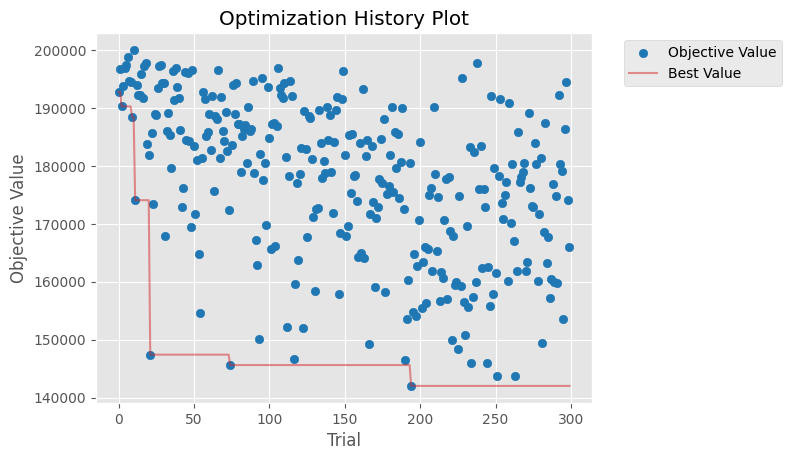


Loading and preprocessing test.csv for submission...
Re-training XGBoost model on 100% of data using best parameters...
Making final predictions on test.csv...

✓ submission_xgb_v3_fine_tuned.csv created successfully!
First few predictions:
            Hospital_Id  Transport_Cost
0          fffe33003400      391.124176
1  fffe3700330036003600        2.191029
2  fffe3300390038003400      280.107391
3      fffe310030003900       99.543640
4  fffe3700330031003200      809.008606


In [10]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import KFold, train_test_split # Need train_test_split again for early stopping eval set
from sklearn.metrics import mean_squared_error
import optuna
from optuna.samplers import TPESampler
from optuna.visualization.matplotlib import plot_optimization_history
import matplotlib.pyplot as plt
import warnings

# --- HIDE NON-CRITICAL WARNINGS ---
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=Warning)

# --- PREPROCESSING FUNCTION (Your Winning v3) ---
def preprocess_data(df, is_train=True, train_stats=None):
    """
    Your winning v3 preprocessing function.
    """
    
    # === 1. Handle Missingness ===
    df['Supplier_Reliability_is_Missing'] = df['Supplier_Reliability'].isna().astype(int)
    
    if is_train:
        stats = {
            'Supplier_Reliability_fill': -1, 
            'Equipment_Height_median': df['Equipment_Height'].median(),
            'Equipment_Width_median': df['Equipment_Width'].median(),
            'Equipment_Weight_median': df['Equipment_Weight'].median(),
            'Equipment_Value_median': df['Equipment_Value'].median()
        }
    else:
        stats = train_stats

    for k, v in stats.items():
        if pd.isna(v): stats[k] = 0

    df['Supplier_Reliability'] = df['Supplier_Reliability'].fillna(stats['Supplier_Reliability_fill'])
    df['Equipment_Height'] = df['Equipment_Height'].fillna(stats['Equipment_Height_median'])
    df['Equipment_Width'] = df['Equipment_Width'].fillna(stats['Equipment_Width_median'])
    df['Equipment_Weight'] = df['Equipment_Weight'].fillna(stats['Equipment_Weight_median'])
    df['Equipment_Value'] = df['Equipment_Value'].fillna(stats['Equipment_Value_median'])
    
    df['Equipment_Type'] = df['Equipment_Type'].fillna('Unknown')
    df['Transport_Method'] = df['Transport_Method'].fillna('Unknown')
    df['Rural_Hospital'] = df['Rural_Hospital'].fillna('Unknown')

    # === 2. Date Feature Engineering (Expanded) ===
    df['Order_Placed_Date'] = pd.to_datetime(df['Order_Placed_Date'], errors='coerce')
    df['Delivery_Date'] = pd.to_datetime(df['Delivery_Date'], errors='coerce')
    df['Delivery_Time_Days'] = (df['Delivery_Date'] - df['Order_Placed_Date']).dt.days
    df['Delivery_Time_Days'] = df['Delivery_Time_Days'].apply(lambda x: 0 if (x < 0 or pd.isna(x)) else x)
    df['Order_Year'] = df['Order_Placed_Date'].dt.year
    df['Order_Month'] = df['Order_Placed_Date'].dt.month
    df['Order_Day_of_Week'] = df['Order_Placed_Date'].dt.dayofweek
    df['Order_Day_of_Year'] = df['Order_Placed_Date'].dt.dayofyear
    df['Order_Quarter'] = df['Order_Placed_Date'].dt.quarter
    df['is_month_start'] = (df['Order_Placed_Date'].dt.day.isin([1, 2])).astype(int)
    df['is_month_end'] = (df['Order_Placed_Date'].dt.is_month_end).astype(int)

    # Fill date NaNs
    if is_train:
        stats['Order_Year_mode'] = df['Order_Year'].mode()[0] if not df['Order_Year'].mode().empty else 2020
        stats['Order_Month_mode'] = df['Order_Month'].mode()[0] if not df['Order_Month'].mode().empty else 1
        stats['Order_Day_of_Week_mode'] = df['Order_Day_of_Week'].mode()[0] if not df['Order_Day_of_Week'].mode().empty else 0
        stats['Order_Day_of_Year_mode'] = df['Order_Day_of_Year'].mode()[0] if not df['Order_Day_of_Year'].mode().empty else 1
        stats['Order_Quarter_mode'] = df['Order_Quarter'].mode()[0] if not df['Order_Quarter'].mode().empty else 1
    
    df['Order_Year'] = df['Order_Year'].fillna(stats['Order_Year_mode'])
    df['Order_Month'] = df['Order_Month'].fillna(stats['Order_Month_mode'])
    df['Order_Day_of_Week'] = df['Order_Day_of_Week'].fillna(stats['Order_Day_of_Week_mode'])
    df['Order_Day_of_Year'] = df['Order_Day_of_Year'].fillna(stats['Order_Day_of_Year_mode'])
    df['Order_Quarter'] = df['Order_Quarter'].fillna(stats['Order_Quarter_mode'])

    # === 3. Physical & Value Feature Engineering (Expanded) ===
    df['Equipment_Area'] = df['Equipment_Height'] * df['Equipment_Width']
    df['Value_per_Weight'] = df['Equipment_Value'] / (df['Equipment_Weight'] + 1e-6)
    df['Equipment_Density'] = df['Equipment_Weight'] / (df['Equipment_Area'] + 1e-6)
    df['Value_per_Area'] = df['Equipment_Value'] / (df['Equipment_Area'] + 1e-6)

    # === 4. Encoding (Binaries and Dummies) ===
    binary_cols = ['CrossBorder_Shipping', 'Urgent_Shipping', 'Installation_Service', 
                   'Fragile_Equipment', 'Rural_Hospital']
    for col in binary_cols:
        if col in df.columns:
            df[col] = df[col].map({'Yes': 1, 'No': 0}).fillna(0) 

    if 'Hospital_Info' in df.columns:
        df['Hospital_Info'] = df['Hospital_Info'].map({'Wealthy': 1, 'Working Class': 0}).fillna(0)
        
    df = pd.get_dummies(df, columns=['Equipment_Type', 'Transport_Method'], drop_first=True)
    
    # === 5. Interaction Feature Engineering ===
    df['Urgent_x_CrossBorder'] = df['Urgent_Shipping'] * df['CrossBorder_Shipping']
    df['Fragile_x_Rural'] = df['Fragile_Equipment'] * df['Rural_Hospital']
    df['Fragile_x_Urgent'] = df['Fragile_Equipment'] * df['Urgent_Shipping']
    
    # === 6. Drop Useless Columns (Original Version) ===
    cols_to_drop = ['Hospital_Id', 'Supplier_Name', 'Hospital_Location', 
                    'Order_Placed_Date', 'Delivery_Date']
    df = df.drop(columns=cols_to_drop, errors='ignore')
    
    if is_train:
        return df, stats
    else:
        return df

# --- 1. LOAD AND PREPROCESS DATA ---
print("Loading and preprocessing data with ADVANCED (v3) features...")
df_train_orig = pd.read_csv("train.csv")
df_train_clean, train_stats = preprocess_data(df_train_orig, is_train=True)

# --- 2. PREPARE FULL TRAINING DATA ---
y_full = df_train_clean['Transport_Cost'].clip(lower=0)
y_full_log = np.log1p(y_full) # Log-transformed target
X_full = df_train_clean.drop(columns=['Transport_Cost'])

# --- 3. K-FOLD VALIDATION ---
print("Using K-Fold Cross-Validation for hyperparameter tuning...")

# --- 4. OPTUNA HYPERPARAMETER TUNING (WITH K-FOLD FOR XGBOOST + EARLY STOPPING FIX) ---
def objective(trial):
    """Define the objective function for Optuna to optimize for XGBoost."""
    params = {
        'objective': 'reg:squarederror', 
        'eval_metric': 'rmse',
        # --- NEW FOCUSED SEARCH SPACE for XGBoost ---
        # Based on best params: {'n_estimators': 1324, 'learning_rate': 0.104..., 'max_depth': 3, ...}
        'n_estimators': trial.suggest_int('n_estimators', 1000, 2500), # Wider range around 1324, ES handles it
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.15, log=True), # Centered around 0.104
        'max_depth': trial.suggest_int('max_depth', 2, 5),               # Centered around 3
        'subsample': trial.suggest_float('subsample', 0.75, 0.95),         # Centered around 0.868
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.65, 0.85), # Centered around 0.774
        'gamma': trial.suggest_float('gamma', 0.01, 0.1, log=True),        # Centered around 0.050
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-6, 1e-3, log=True), # Range covering very small value
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 0.1, log=True),   # Centered around 0.031
        'random_state': 42,
        'n_jobs': -1,
        'tree_method': 'hist',
        'early_stopping_rounds': 50 
    }
    
    model = xgb.XGBRegressor(**params) 
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmses = []

    for fold, (train_index, val_index) in enumerate(kf.split(X_full)):
        X_train_k, X_val_k = X_full.iloc[train_index], X_full.iloc[val_index]
        y_train_k = y_full_log.iloc[train_index]
        y_val_k_dollar = y_full.iloc[val_index]
        
        # --- Create Evaluation Set for Early Stopping (within the fold) ---
        X_train_fold, X_eval_fold, y_train_fold, y_eval_fold = train_test_split(
            X_train_k, y_train_k, test_size=0.15, random_state=42 + fold 
        )
        
        # --- Fit with Early Stopping ---
        model.fit(X_train_fold, y_train_fold, 
                  eval_set=[(X_eval_fold, y_eval_fold)], 
                  verbose=False) 
        
        # Predict on the main K-Fold validation set
        best_iteration = model.best_iteration if hasattr(model, 'best_iteration') else None
        preds_log = model.predict(X_val_k, iteration_range=(0, best_iteration) if best_iteration is not None else None)
        preds_dollar = np.expm1(preds_log)
        
        rmse = np.sqrt(mean_squared_error(y_val_k_dollar, preds_dollar))
        rmses.append(rmse)
    
    return np.mean(rmses)

print("\nStarting FINE-TUNED hyperparameter search for XGBoost (300 trials, 5-Fold CV)...")
print("!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")
print("!!! WARNING: This will take ~5x longer to complete.    !!!")
print("!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")

sampler = TPESampler(seed=42)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=300) 

best_params = study.best_params
best_params.pop('early_stopping_rounds', None) 

print("\n--- OPTUNA FINE-TUNING COMPLETE ---")
print(f"Best 5-Fold CV RMSE found: ${study.best_value:,.2f}")
print("Best parameters found:")
print(best_params)
print("----------------------------\n")

# --- 5. VISUALIZE THE OPTIMIZATION HISTORY WITH MATPLOTLIB ---
print("Displaying optimization history plot...")
plot_optimization_history(study)
plt.show()

# --- 6. PREPARE FINAL TEST DATA FOR SUBMISSION ---
print("\nLoading and preprocessing test.csv for submission...")
df_test_orig = pd.read_csv("test.csv")
submission_ids = df_test_orig['Hospital_Id'].copy()
df_test_clean = preprocess_data(df_test_orig, is_train=False, train_stats=train_stats)

X_test_final = df_test_clean.reindex(columns=X_full.columns, fill_value=0)

# --- 7. RE-TRAIN MODEL ON 100% OF DATA WITH BEST PARAMS ---
print("Re-training XGBoost model on 100% of data using best parameters...")
y_full_log = np.log1p(y_full)

final_model = xgb.XGBRegressor(**best_params, random_state=42, n_jobs=-1) 
final_model.fit(X_full, y_full_log, verbose=False) # Train on ALL data

# --- 8. MAKE FINAL PREDICTIONS ---
print("Making final predictions on test.csv...")
preds_log = final_model.predict(X_test_final)
preds_dollar = np.expm1(preds_log)
preds_dollar = np.maximum(preds_dollar, 0)

# --- 9. CREATE SUBMISSION FILE ---
submission = pd.DataFrame({'Hospital_Id': submission_ids, 'Transport_Cost': preds_dollar})
submission.to_csv("submission_xgb_v3_fine_tuned.csv", index=False)

print(f"\n✓ submission_xgb_v3_fine_tuned.csv created successfully!")
print("First few predictions:")
print(submission.head())
